<link rel="stylesheet" href="notebooks/styles.css">

<div class="title-wrap">
  <h1 class="title-main" style="font-weight: bold; font-size: 2.65rem; margin-bottom: 0.5rem;">
  Spatial Data Science Approaches to Wildfire Severity Modeling
</h1>
<h2 class="title-sub" style="font-style: italic; font-size: 1.8rem; margin-top: 0rem; margin-bottom: 0.2rem;">
  A GIS‑Driven, Tree‑Based Machine Learning Analysis of California Wildfires
</h2>
</div>

# Module 4: *Variable Selection*
##### Version Number: 4.0
---
### Contents  
> 1. *Water Demand*
> 2. *Water Supply*
> 3. *Water Supply Indexes*
> 4. *Fire Danger Indicators*
> 5. *Social Variables*
> 6. *Temporal and Geographic Varaibles*
> 7. *Export File*
---
### Notes
- This module visualizes key variables to assess their relationships with wildfire severity categories. Based on the `Categorical` target, we explore how different weather features interact and correlate with fire risk.
---
### Inputs
- `engineered_samples.csv` engineered and cleaned samples data with weather, fire, and grid data.
---
### Outputs 
- `X`,`y`,`details` - Split training data filtered from 2018 to 2024
- `pal_x`, `pal_y`, `pal_details` - Split training data from 2025 for case study
---
### User Defined Dependencies

In [1]:
import os
import sys

# Allow import of custom modules from the parent directory
sys.path.append(os.path.abspath(os.path.join('..')))

from src.data_utils import *
from src.model_utils import *
from src.plot_utils import *

---
### Third Party Dependencies

In [2]:
# Core data tools
import pandas as pd
import numpy as np
from datetime import datetime
import json

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

# Set consistent plotting style
sns.set(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

---

In [3]:
def plot_all(df, target1, target2, target3, title):
    grid_kde(df)

### Loading Data

In [4]:
samples = pd.read_csv('../data/processed/engineered_samples.csv')

---

## Split dataset temporarily for variable analysis

In [5]:
# Columns to drop for feature interaction analysis
text_columns = ['Sample_ID', 'Date', 'grid_id',
       'geometry', 'fire_count', 'total_fire_damage','acres','area_in_cali','maximum_x', 'minimum_y',
       'maximum_y', 'minimum_x','centroid_northing','centroid_easting','Target_Damage','Target_Ignition',
               'Target_Spread','Year','acres_per_day','damage_per_day','acres_burned_so_far','damage_so_far']

coded_columns = ['dominant_province_description','dominant_section_description','Season']

numerical_data = samples.drop(columns=text_columns + coded_columns)
detail_data = samples[text_columns]

target_ignition = samples['Target_Ignition']
target_spread = samples['Target_Spread']
target_damage = samples['Target_Damage']

## Scale numerical columns for easier side by side comparisons

In [6]:
scaler = MinMaxScaler()

# Scale main dataset
X_scaled = scaler.fit_transform(numerical_data)
X = pd.DataFrame(X_scaled, columns=numerical_data.columns, index=numerical_data.index)

X = pd.concat([X,samples[coded_columns]],axis=1)

## DIrect Water Demand Indicators

In [7]:
water_demand = [
    "Actual Evapotranspiration",
    "Solar Radiation",
    "Daily Minimum Air Temperature",
    "Daily Maximum Air Temperature",
    "Vapor Pressure Deficit",
    "Wind Speed",
]

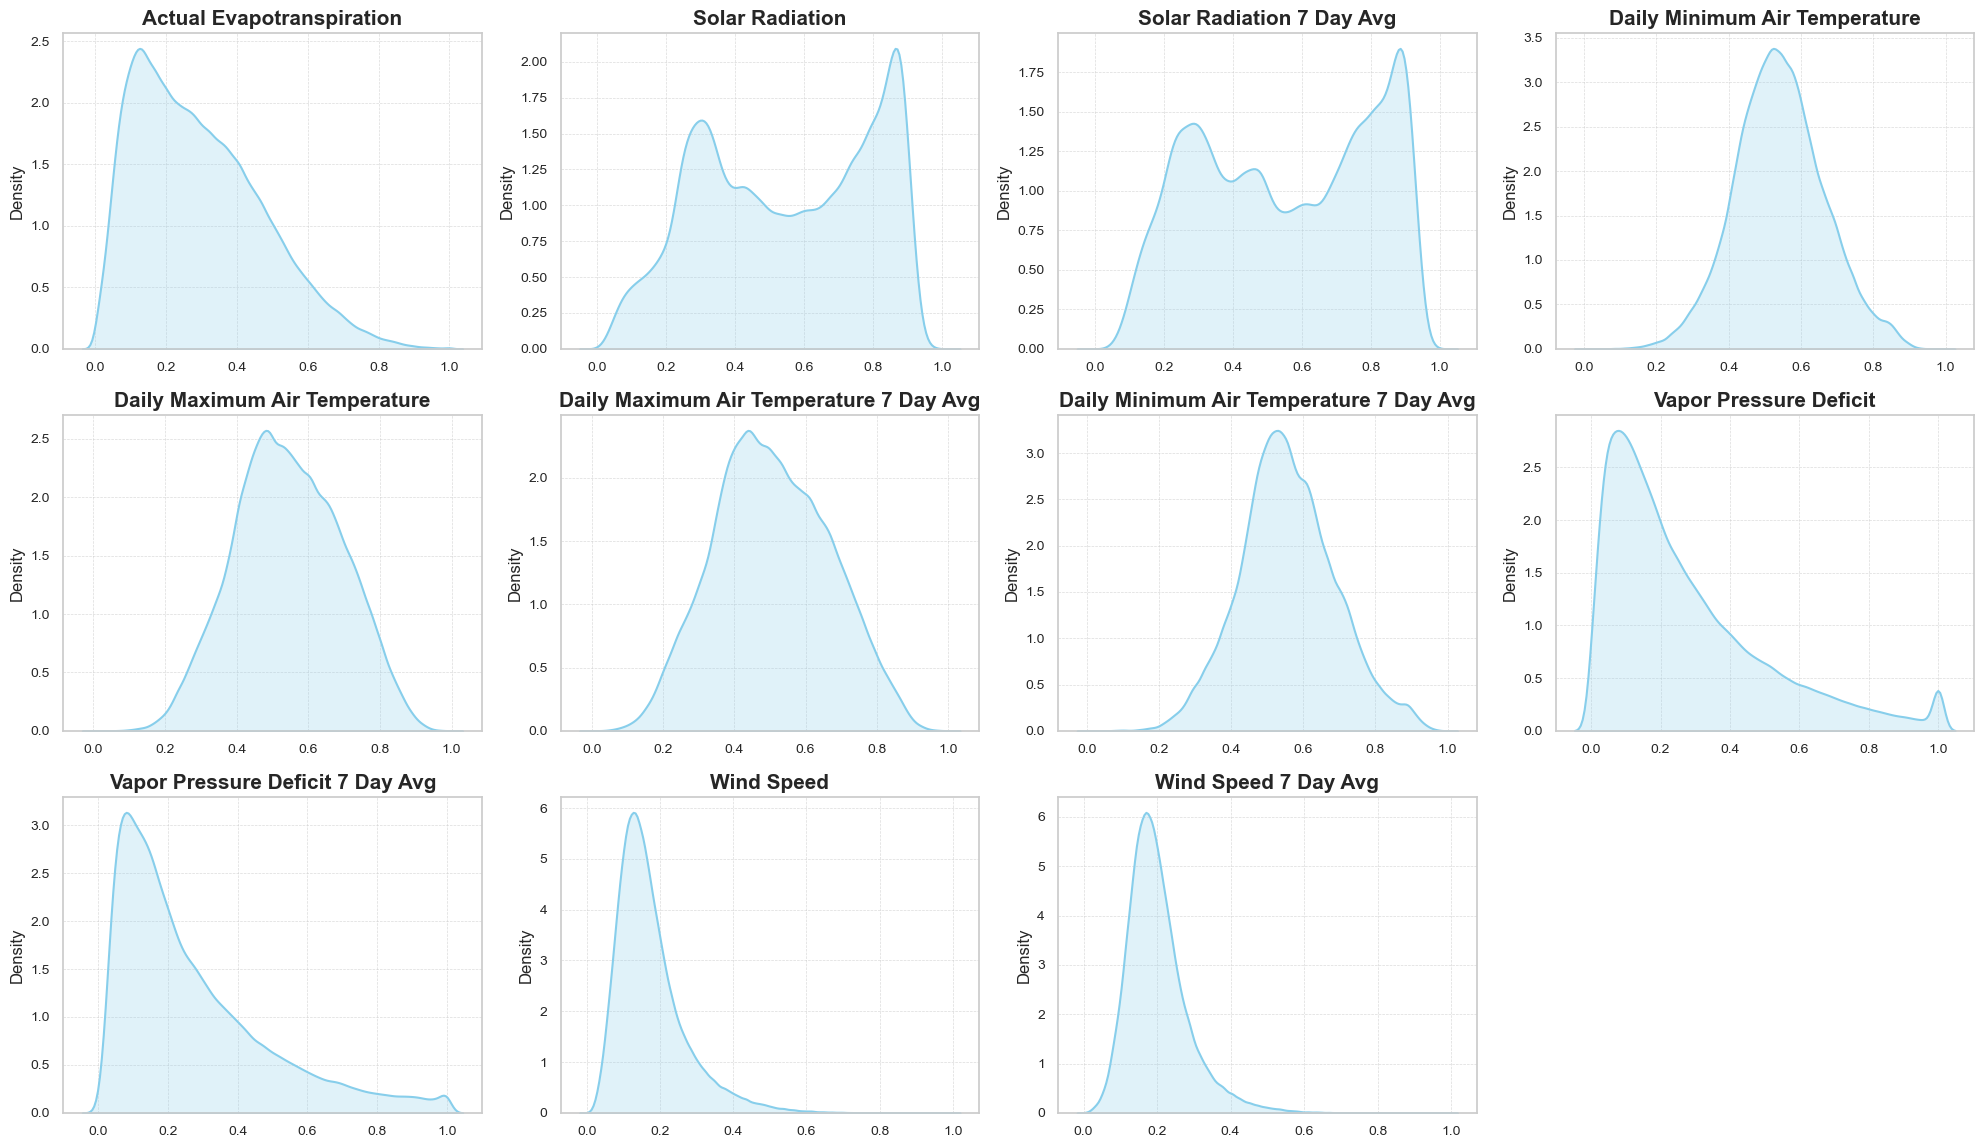

In [8]:
plot_all(X[water_demand], target_ignition, target_spread,target_damage, 'Water Demand')

---

## Water Supply Indicators

In [9]:
water_supply = [
    "Precipitation",
    "Maximum Relative Humidity",
    "Minimum Relative Humidity",
    "Specific Humidity",
    "100-hour Dead Fuel Moisture",
    "1000-hour Dead Fuel Moisture"
]

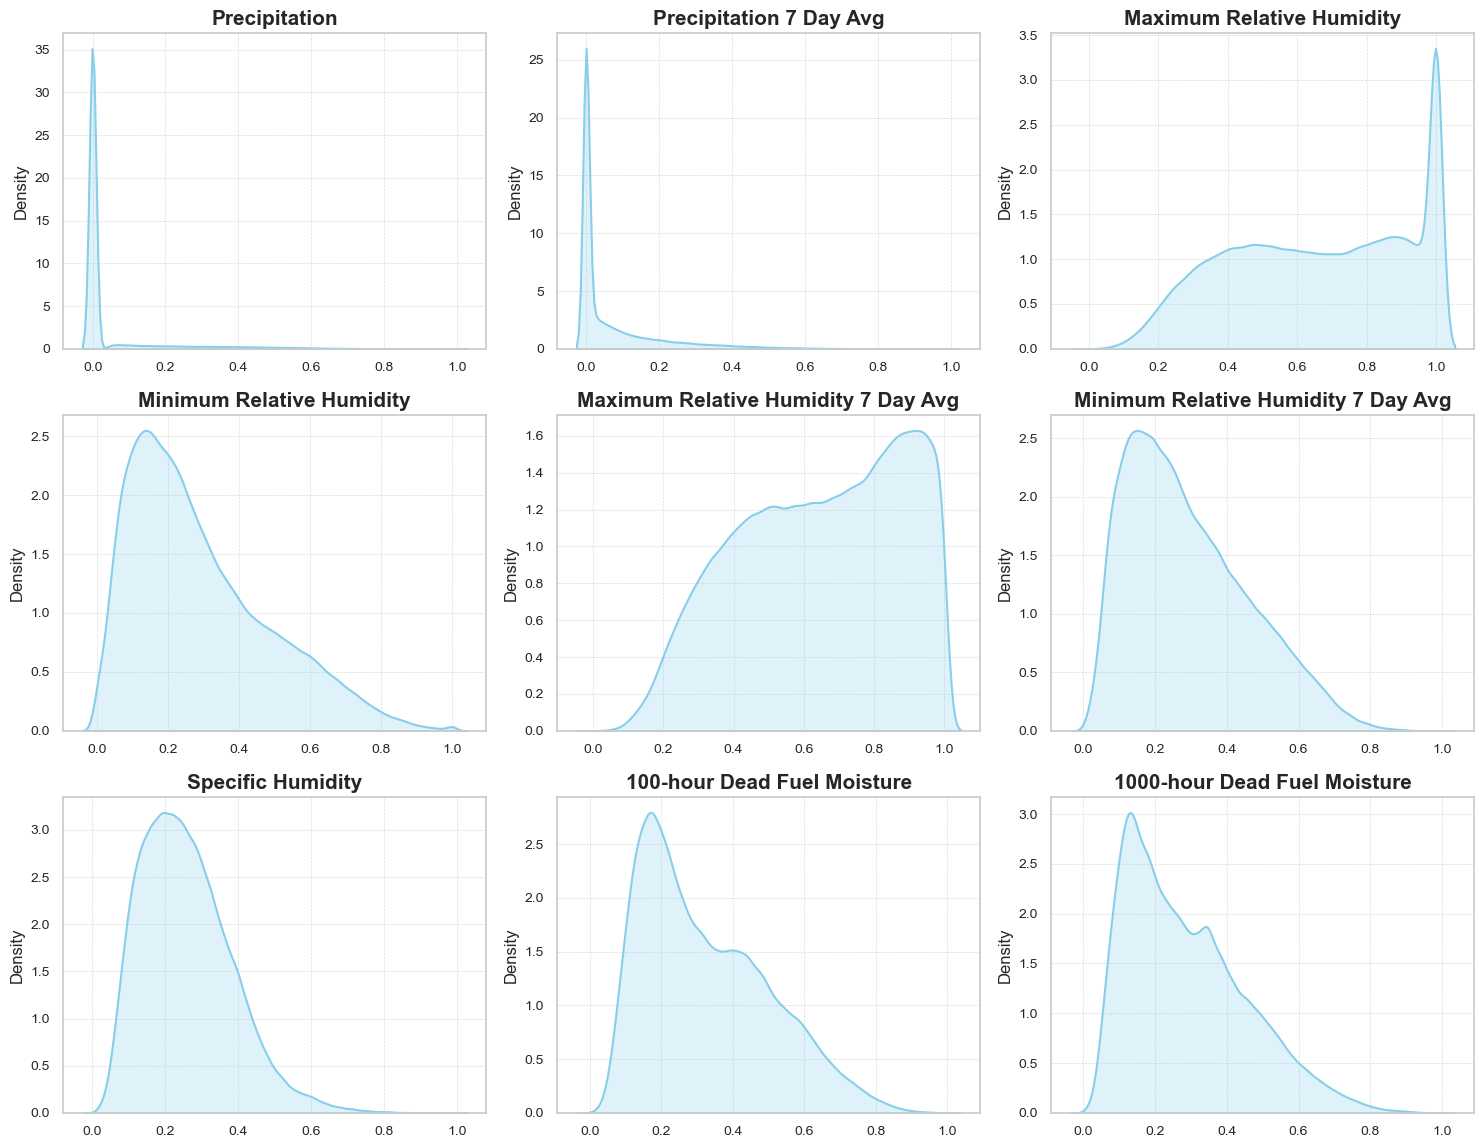

In [10]:
plot_all(X[water_supply], target_ignition, target_spread,target_damage,'Water Supply')

---

## Water Supply Indexes

In [11]:
water_supply_indexes = ["SPI 30-Day",
    "SPI 180-Day",
    "SPEI 30-Day",
    "SPEI 90-Day",
    "SPEI 180-Day",
    "Palmer Drought Severity Index"
]

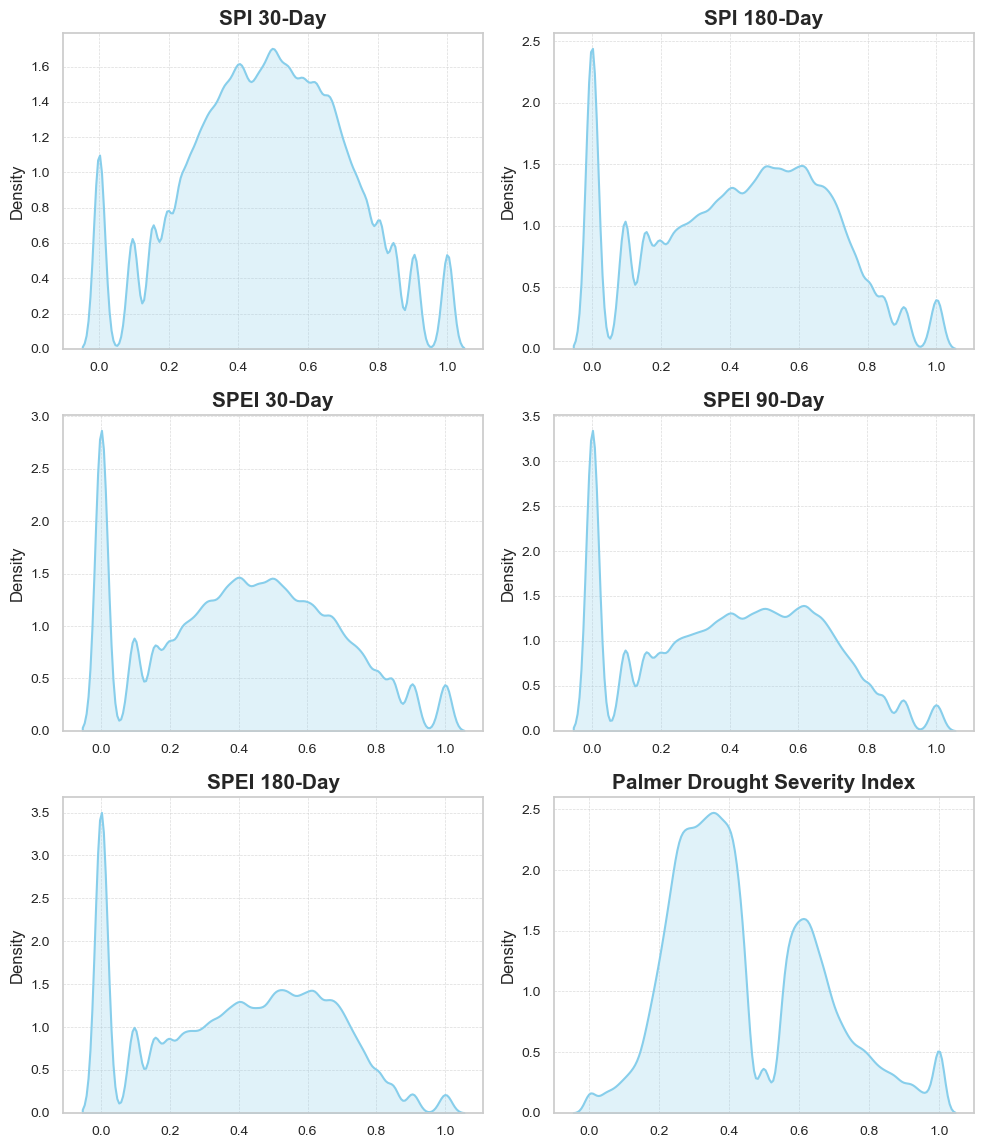

In [12]:
plot_all(X[water_supply_indexes], target_ignition, target_spread,target_damage,'Water Supply Indexes')

## Fire Danger

In [13]:
fire_danger = [
    "Burning Index",
    "Energy Release Component",
    'Santa_Ana_Score']

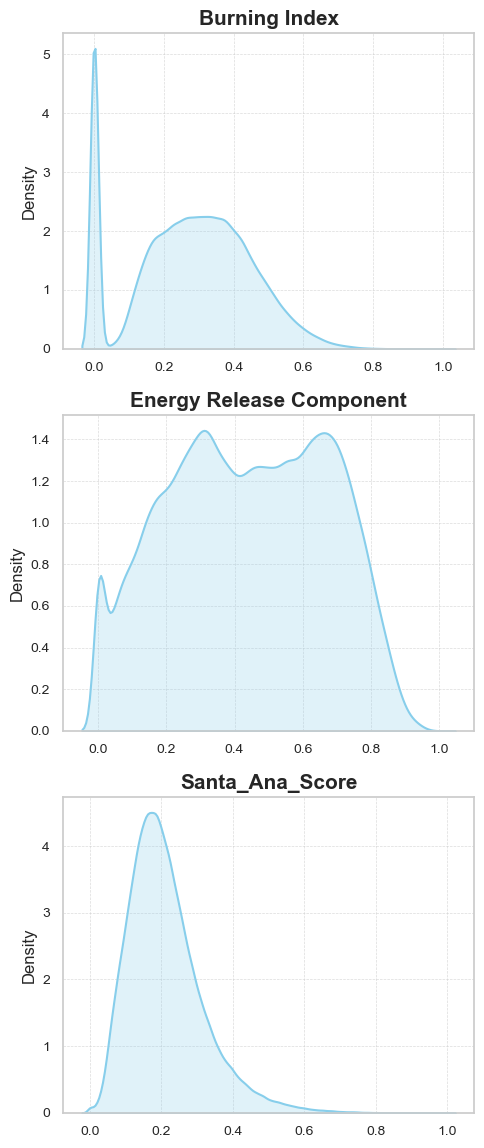

In [14]:
plot_all(X[fire_danger], target_ignition, target_spread,target_damage,'Fire Danger')

## Social Variables

In [15]:
social = ['total_housing', 'total_population',
       'housing_density', 'population_density', 'median_income']

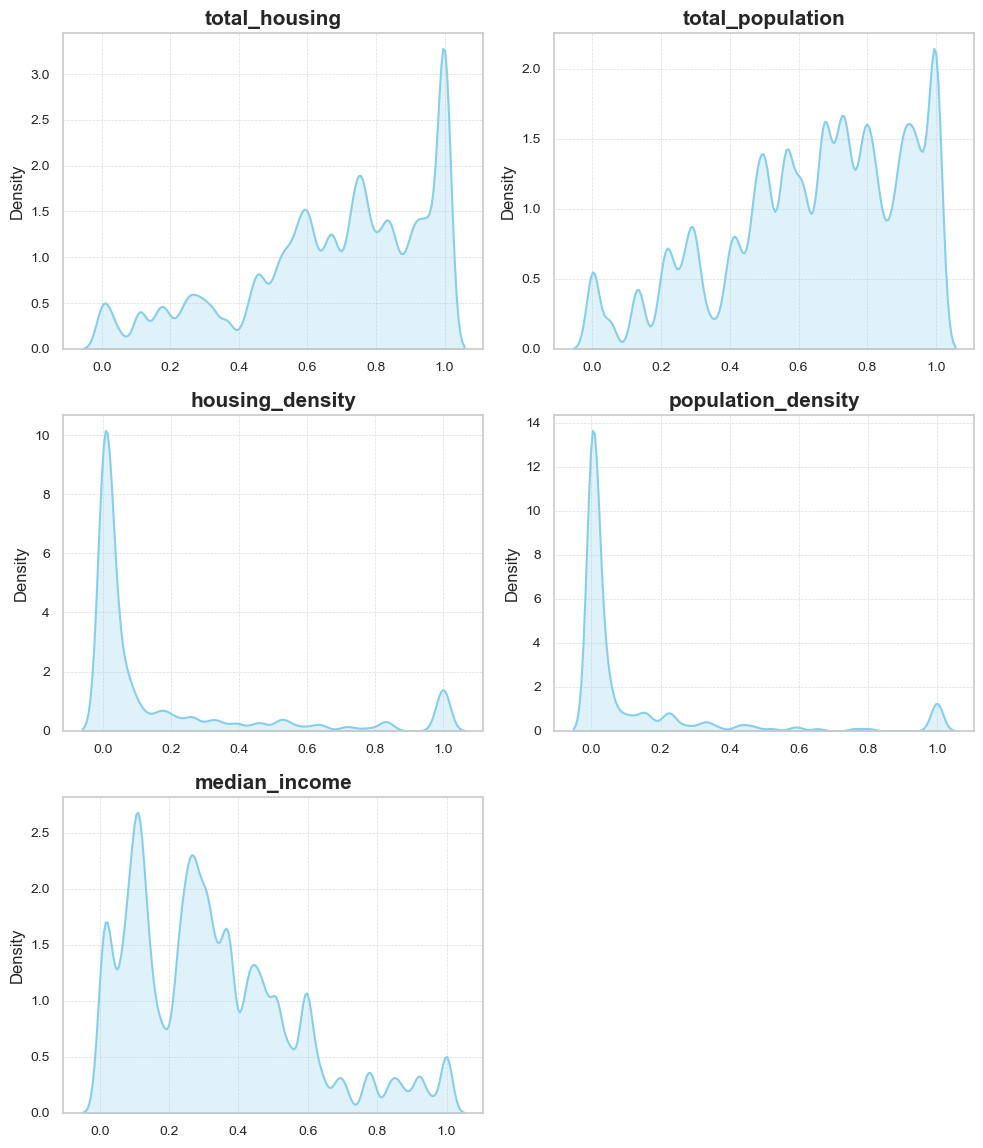

In [16]:
plot_all(X[social], target_ignition, target_spread,target_damage,'Social')

## Infrastructure

In [17]:
infrastructure = ['power_line_meters','power_line_density','road_length_meters','road_density']

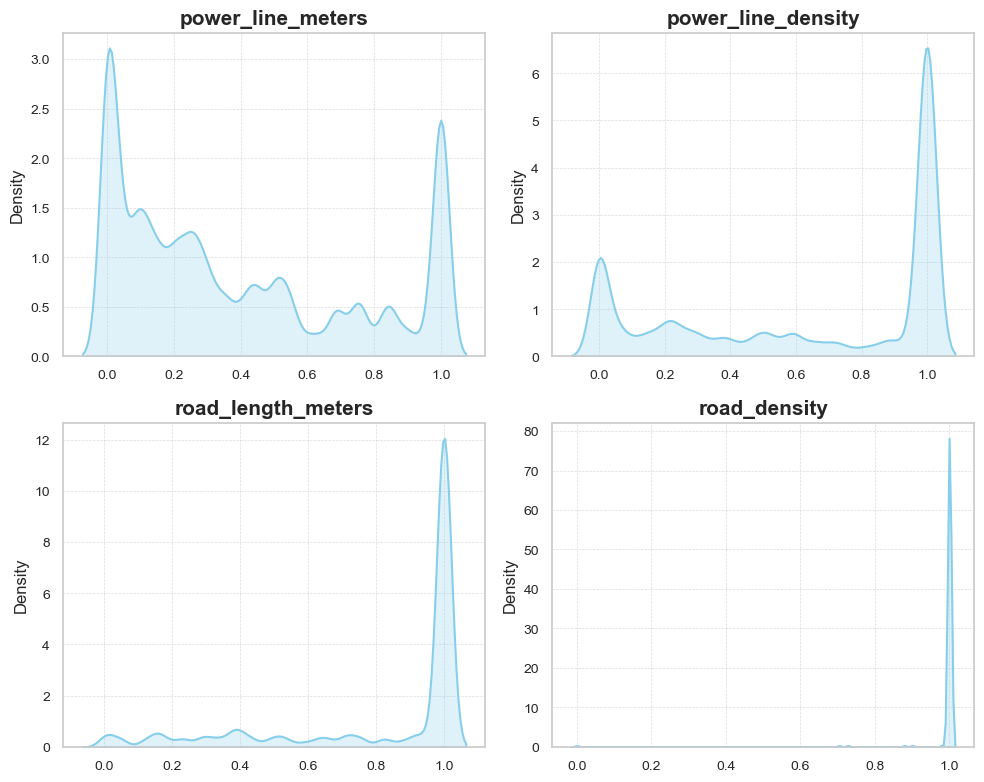

In [18]:
plot_all(X[infrastructure], target_ignition, target_spread,target_damage,'Infrastructure')

## Elevation

In [19]:
elevation = ['elevation_range', 'elevation_mean',
       'elevation_std', 'slope_max', 'slope_range', 'slope_mean', 'slope_std',
       'northness_mean', 'eastness_mean']

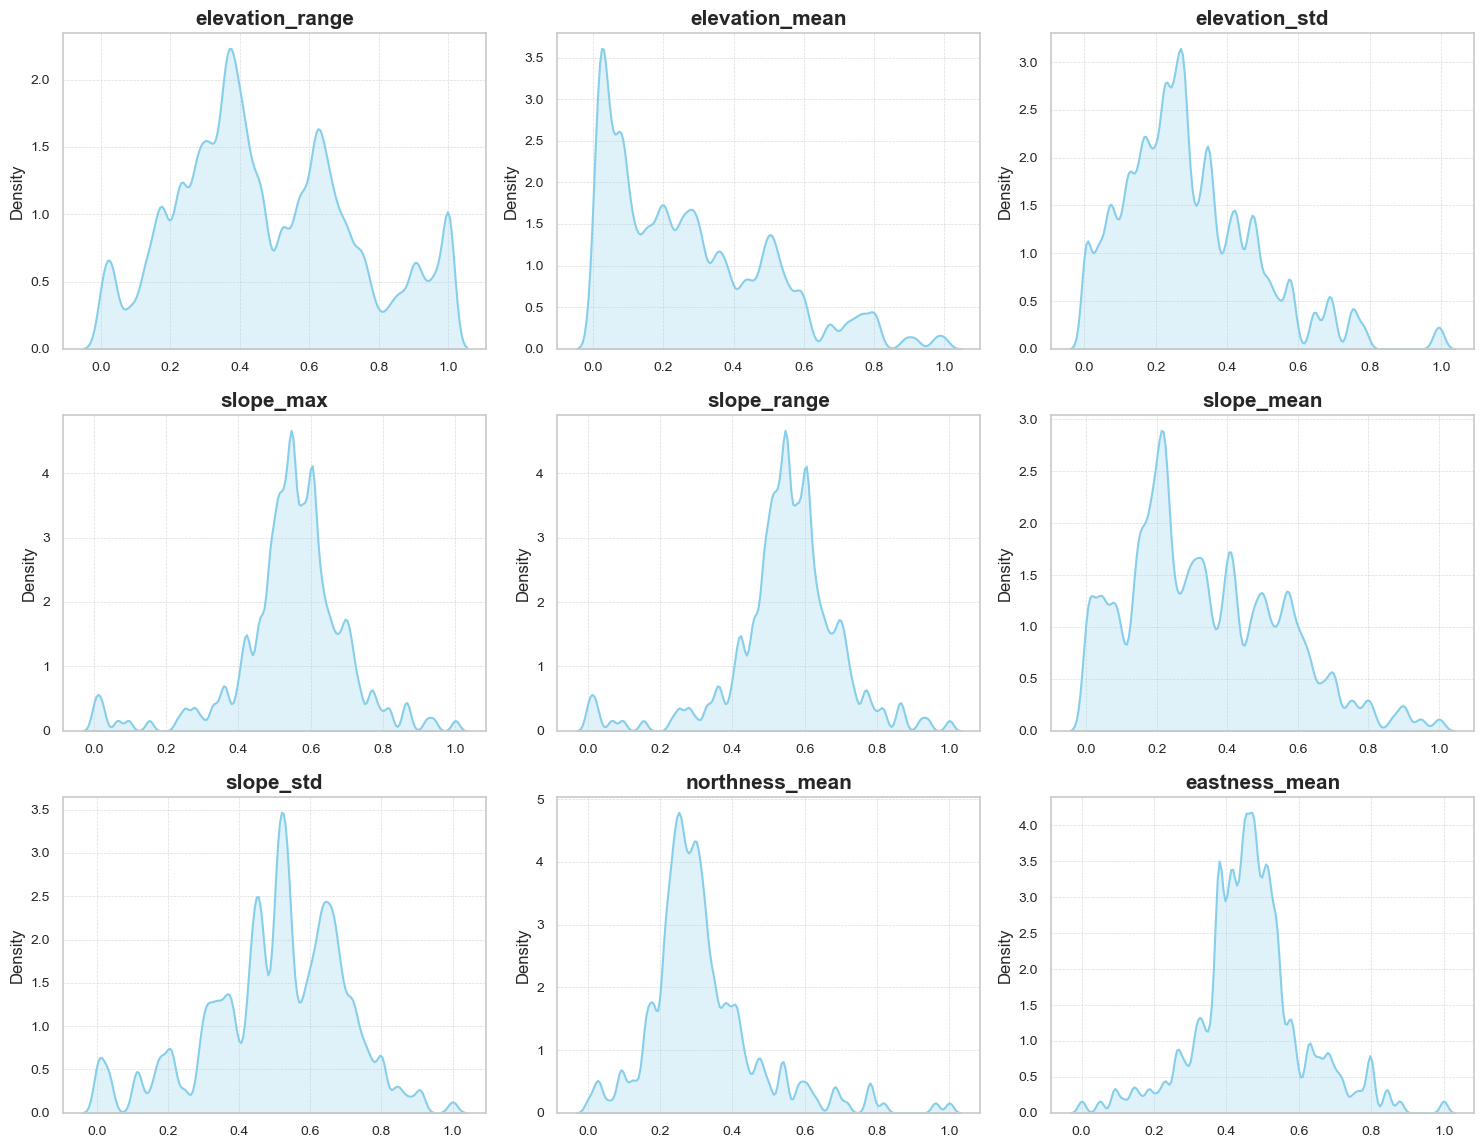

In [20]:
plot_all(X[elevation], target_ignition, target_spread,target_damage,'Elevation')

## WUI

In [21]:
WUI = ['influence_zone', 'interface_zone', 'intermix_zone']

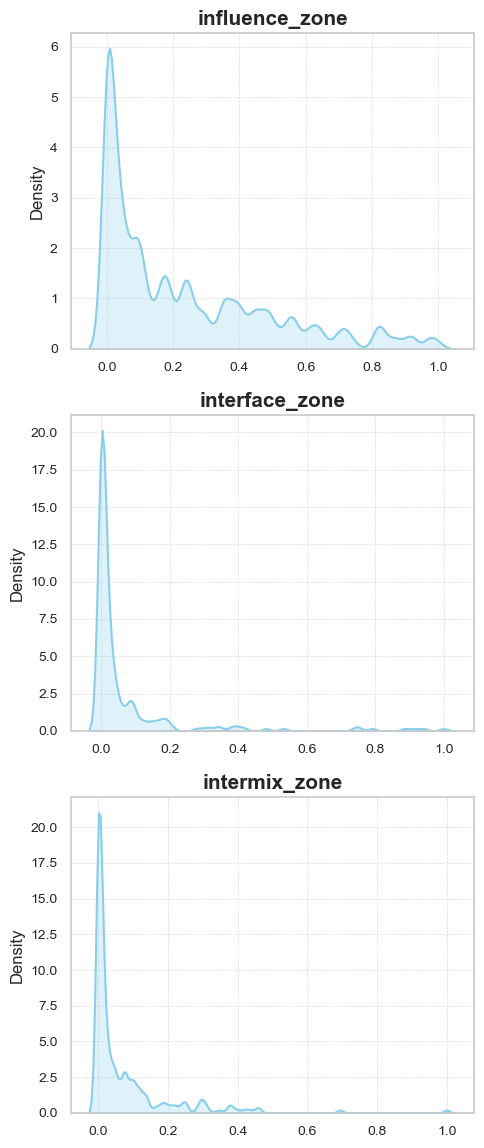

In [22]:
plot_all(X[WUI], target_ignition, target_spread,target_damage,'WUI')

## Ecological

In [23]:
ecoregion = ['dominant_province_percent', 'sum_province_area', 'sum_section_area',
       'dominant_section_percent']

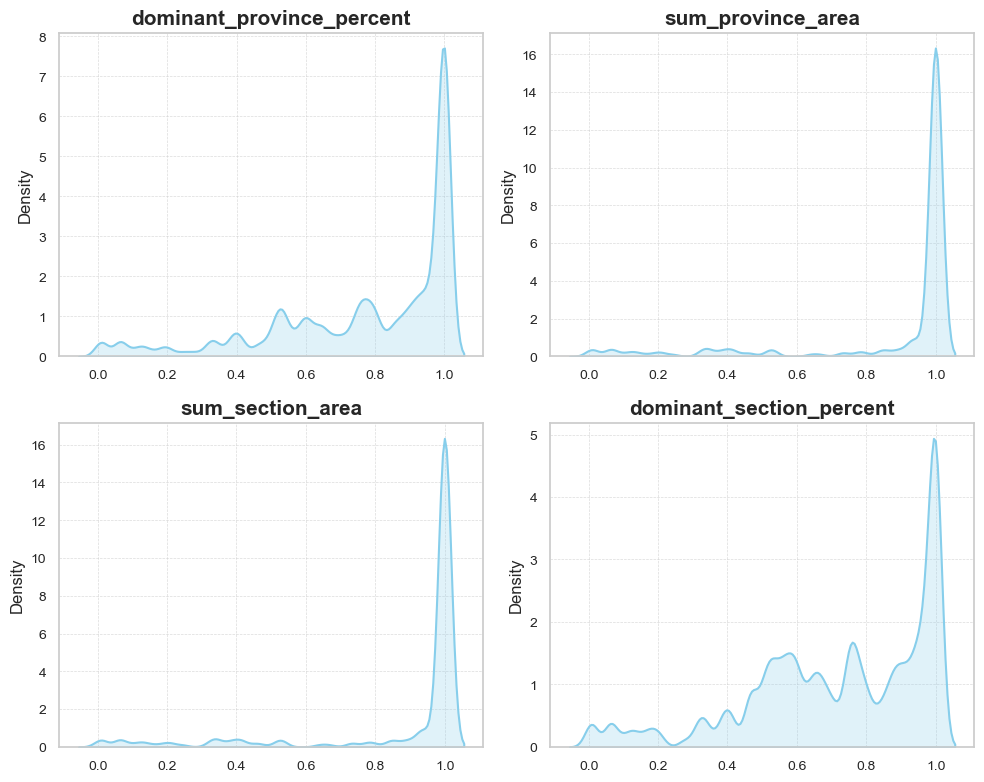

In [24]:
plot_all(X[ecoregion], target_ignition, target_spread,target_damage,'Ecological')

## Land Cover

In [25]:
land_cover = ['forest_percent','developed_percent', 'other_percent', 'shrub_grass_percent',
       'wetlands_percent']

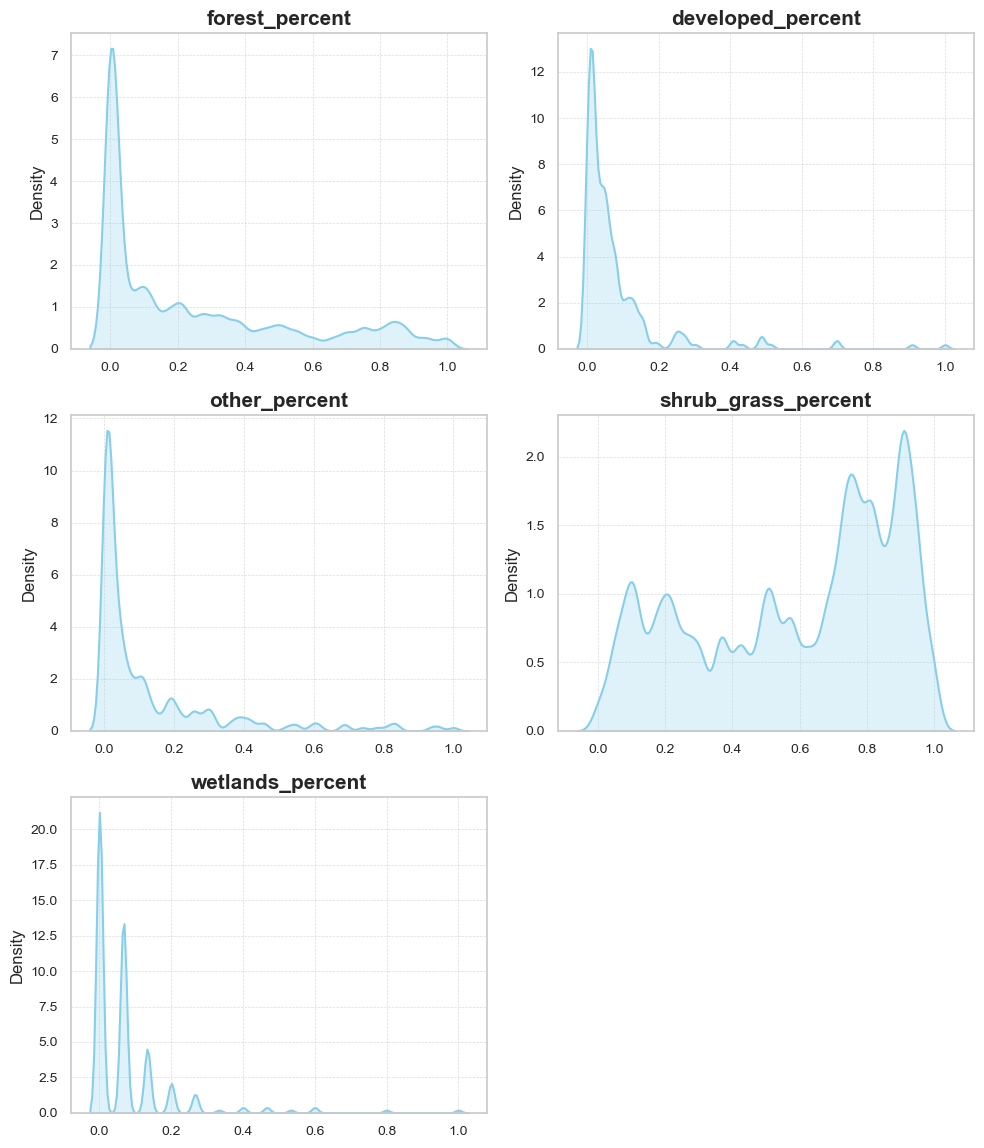

In [26]:
plot_all(X[land_cover], target_ignition, target_spread,target_damage,'Land Cover')

---

In [27]:
interactions = ['Wind Speed_x_100-hour Dead Fuel Moisture',
 'Vapor Pressure Deficit_x_Solar Radiation',
 'Precipitation_x_1000-hour Dead Fuel Moisture',
 'northness_mean_x_Daily Maximum Air Temperature',
 'road_density_x_forest_percent',
 'power_line_density_x_total_housing']

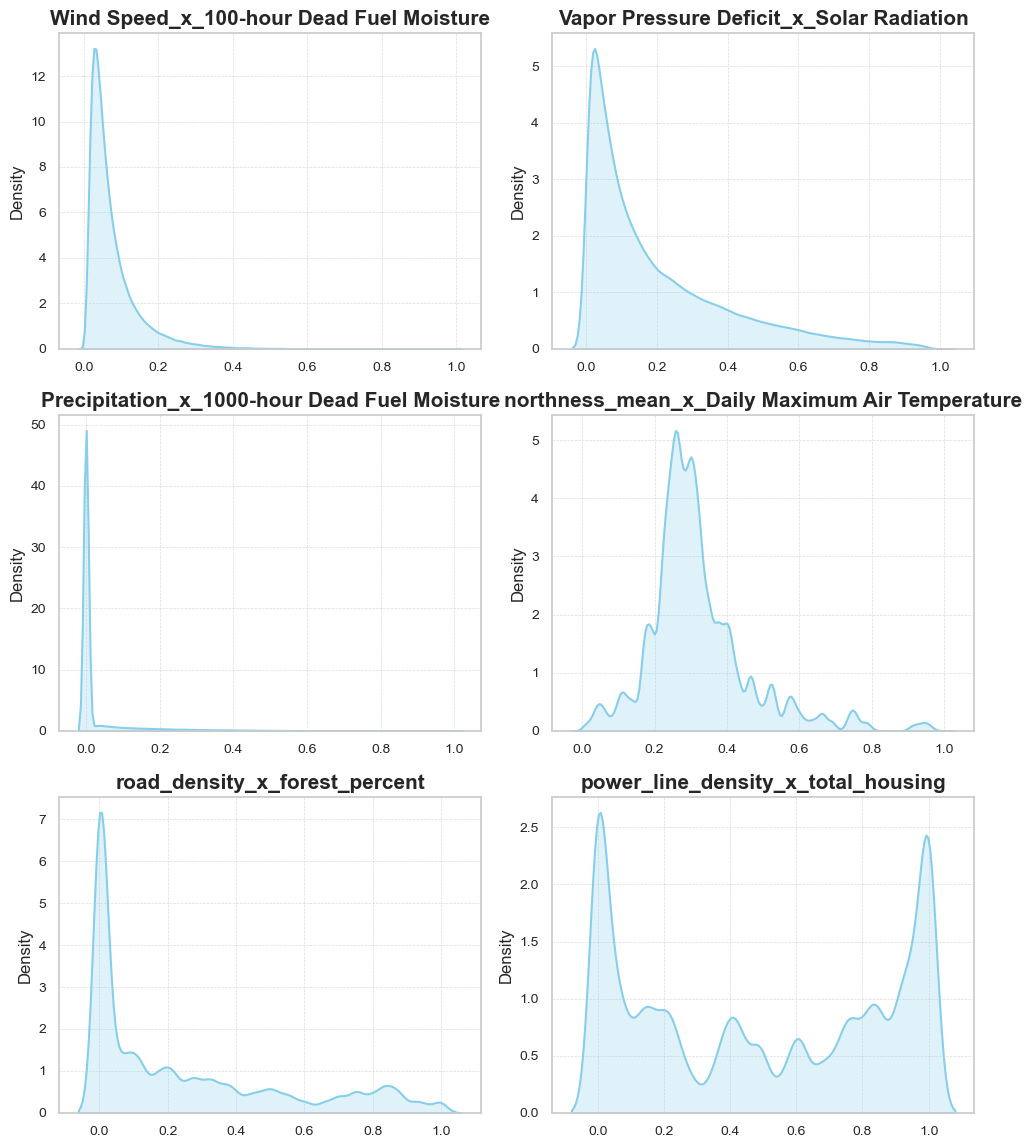

In [28]:
plot_all(X[interactions], target_ignition, target_spread,target_damage,'Interactions')

## Wind Slope Interaction

In [29]:
wind_slope = ['Wind Speed_x_slope_mean',
 'Wind Speed_x_slope_max',
 'Wind Speed_x_northness_mean',
 'Wind Speed_x_eastness_mean',
 'Wind Speed_x_elevation_mean',
 'Wind Speed_x_elevation_range',
 'Wind Speed 7 Day Avg_x_slope_mean',
 'Wind Speed 7 Day Avg_x_slope_max',
 'Wind Speed 7 Day Avg_x_northness_mean',
 'Wind Speed 7 Day Avg_x_eastness_mean',
 'Wind Speed 7 Day Avg_x_elevation_mean',
 'Wind Speed 7 Day Avg_x_elevation_range']

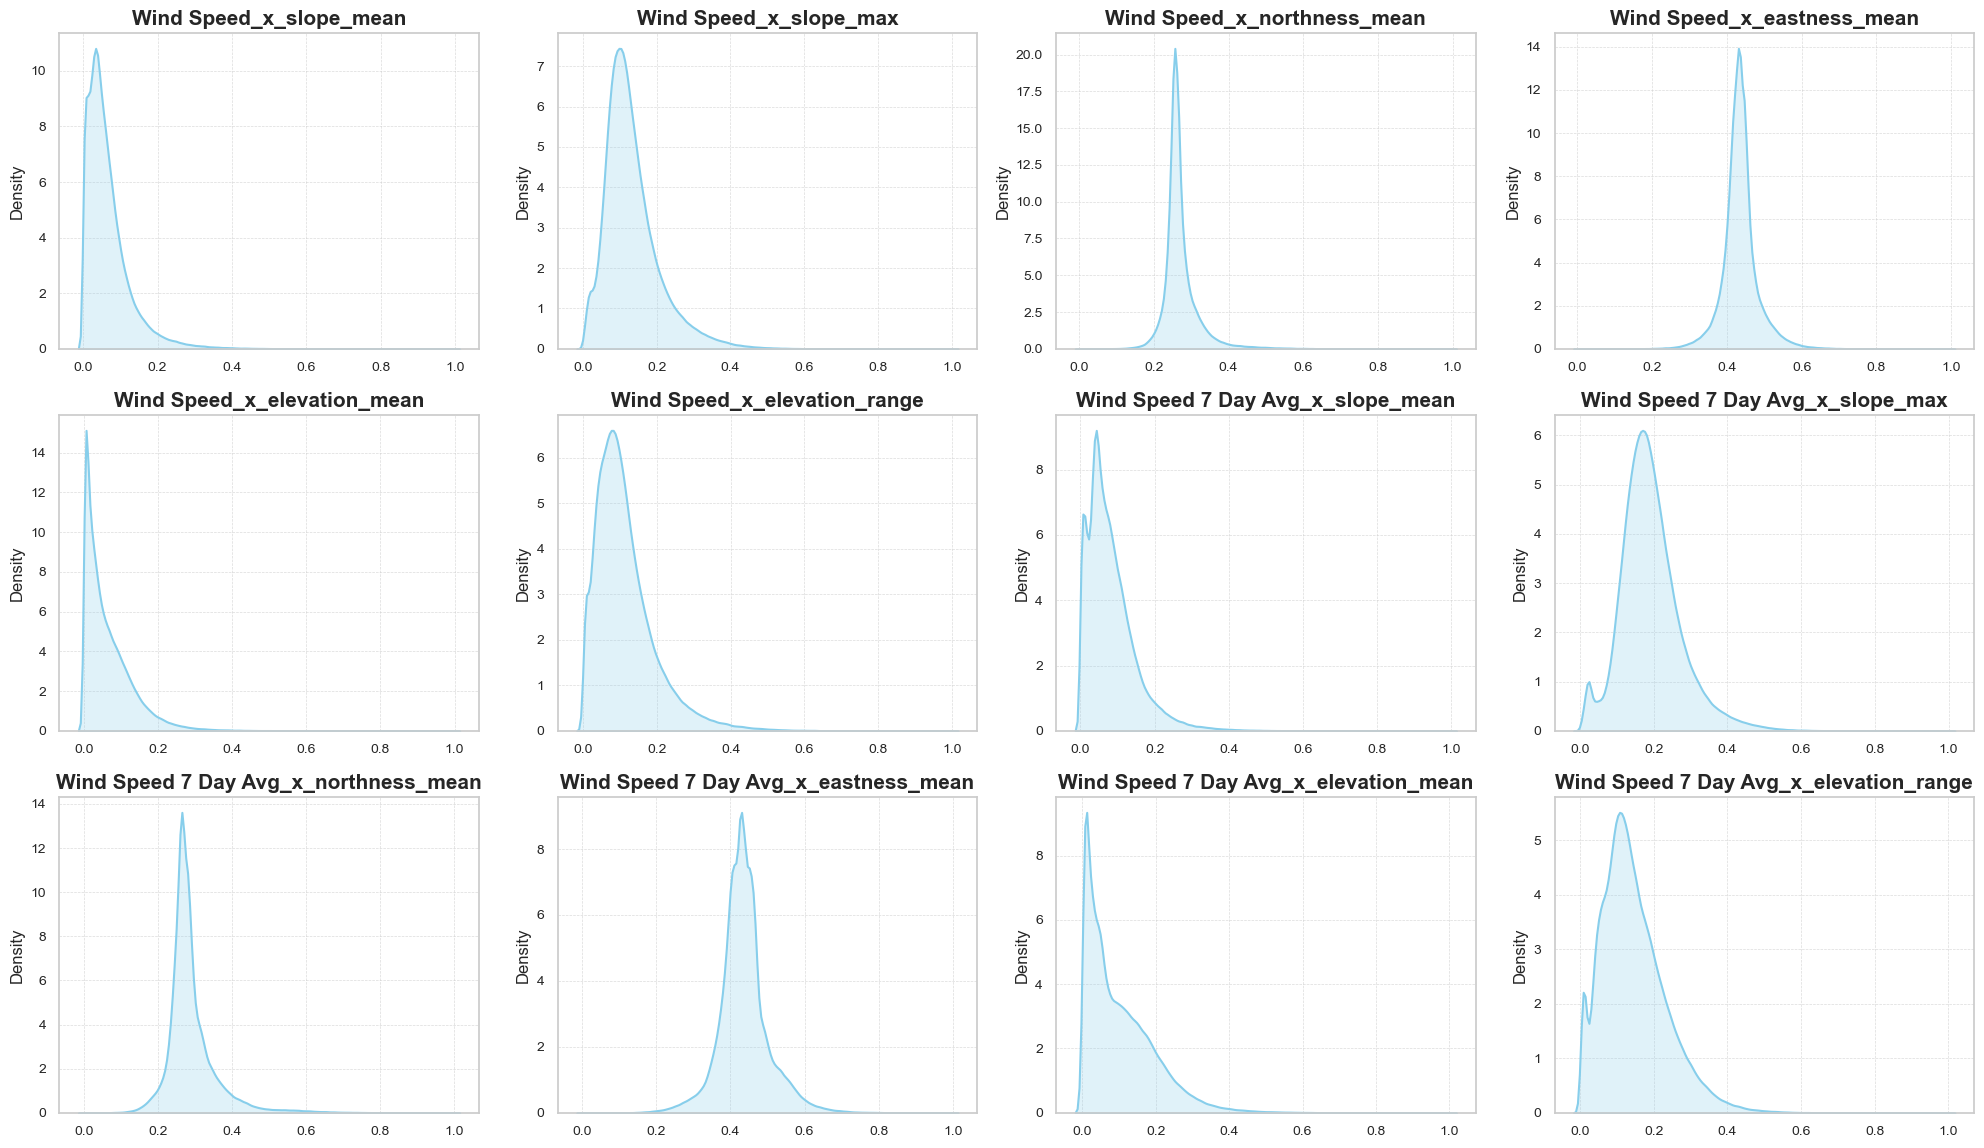

In [30]:
plot_all(X[wind_slope], target_ignition, target_spread,target_damage,'Wind Slope Interactions')

## Wildfire Features

In [ ]:
wildfire = ['yesterday_fire_count','yesterday_total_fire_damage','yesterday_acres',
                'yesterday_acres_per_day','yesterday_damage_per_day','yesterday_acres_burned_so_far','yesterday_damage_so_far',
                'yesterday_Target_Ignition','yesterday_Target_Spread','yesterday_Target_Damage']

In [ ]:
plot_all(X[wildfire], target_ignition, target_spread,target_damage,'wildfire')

## Other Features

In [31]:
others = [
    "NDVI_mean_difference",
    "NDVI_mean_difference_has_value",
    'reservoir_count',
    'total_reservoir_level',
    'stations_missing_levels'
]

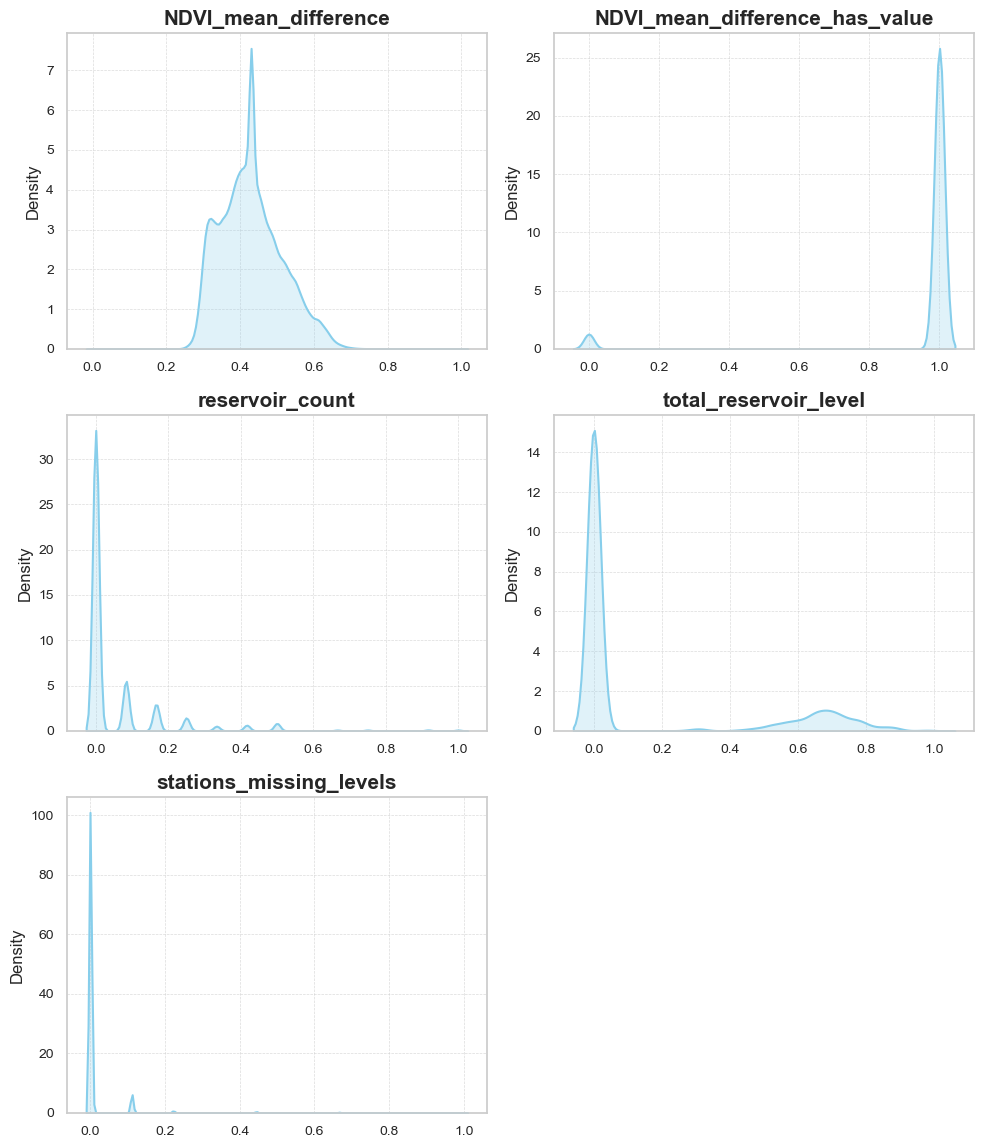

In [32]:
plot_all(X[others], target_ignition, target_spread,target_damage,'Wind Slope Interactions')

In [33]:
coded_ecoregion = [
    # Province
    "dominant_province_description_American Semi-Desert and Desert",
    "dominant_province_description_California Coastal Chaparral Forest and Shrub",
    "dominant_province_description_California Coastal Range Open Woodland-Shrub-Coniferous Forest-Meadow",
    "dominant_province_description_California Coastal Steppe-Mixed Forest-Redwood Forest",
    "dominant_province_description_California Dry Steppe",
    "dominant_province_description_Intermountain Semi-Desert",
    "dominant_province_description_Intermountain Semi-Desert and Desert",
    "dominant_province_description_Sierran Steppe-Mixed Forest-Coniferous Forest-Alpine Meadow",

    # Section
    "dominant_section_description_Central California Coast",
    "dominant_section_description_Central Valley Coast Ranges",
    "dominant_section_description_Colorado Desert",
    "dominant_section_description_Great Valley",
    "dominant_section_description_Klamath Mountains",
    "dominant_section_description_Modoc Plateau",
    "dominant_section_description_Mojave Desert",
    "dominant_section_description_Mono",
    "dominant_section_description_Northern California Coast",
    "dominant_section_description_Northern California Coast Ranges",
    "dominant_section_description_Northern California Interior Coast Ranges",
    "dominant_section_description_Northwestern Basin and Range",
    "dominant_section_description_Sierra Nevada",
    "dominant_section_description_Sierra Nevada Foothills",
    "dominant_section_description_Sonoran Desert",
    "dominant_section_description_Southeastern Great Basin",
    "dominant_section_description_Southern California Coast",
    "dominant_section_description_Southern California Mountains and Valleys",
    "dominant_section_description_Southern Cascades"
]

In [34]:
coded_seasons =[
    'Season_Spring',
    'Season_Summer',
    'Season_Fall',
    'Season_Winter'
]

In [ ]:
    'yesterday_fire_count',
    'yesterday_total_fire_damage',
    'yesterday_acres',
    'yesterday_Target_Ignition',
    'yesterday_Target_Spread',
    'yesterday_Target_Damage'
    'yesterday_acres_per_day',
    'yesterday_damage_per_day'

# 3-day lagged features
lag_3_day = [
    "Actual Evapotranspiration 3 Day Avg",
    "Solar Radiation 3 Day Avg",
    "Daily Minimum Air Temperature 3 Day Avg",
    "Daily Maximum Air Temperature 3 Day Avg",
    "Vapor Pressure Deficit 3 Day Avg",
    "Wind Speed 3 Day Avg",
    "Precipitation 3 Day Avg",
    "Maximum Relative Humidity 3 Day Avg",
    "Minimum Relative Humidity 3 Day Avg",
    "Specific Humidity 3 Day Avg",
    "100-hour Dead Fuel Moisture 3 Day Avg",
    "1000-hour Dead Fuel Moisture 3 Day Avg",
    "Burning Index 3 Day Avg",
    "Energy Release Component 3 Day Avg",
    "yesterday_fire_count 3 Day Avg",
    "yesterday_total_fire_damage 3 Day Avg",
    "yesterday_acres 3 Day Avg",
    "yesterday_Target_Ignition 3 Day Avg",
    "yesterday_Target_Spread 3 Day Avg",
    "yesterday_Target_Damage 3 Day Avg",
    "yesterday_acres_per_day 3 Day Avg",
    "yesterday_damage_per_day 3 Day Avg",
]

# 7-day lagged features
lag_7_day = [
    "Actual Evapotranspiration 7 Day Avg",
    "Solar Radiation 7 Day Avg",
    "Daily Minimum Air Temperature 7 Day Avg",
    "Daily Maximum Air Temperature 7 Day Avg",
    "Vapor Pressure Deficit 7 Day Avg",
    "Wind Speed 7 Day Avg",
    "Precipitation 7 Day Avg",
    "Maximum Relative Humidity 7 Day Avg",
    "Minimum Relative Humidity 7 Day Avg",
    "Specific Humidity 7 Day Avg",
    "100-hour Dead Fuel Moisture 7 Day Avg",
    "1000-hour Dead Fuel Moisture 7 Day Avg",
    "Burning Index 7 Day Avg",
    "Energy Release Component 7 Day Avg",
    "yesterday_fire_count 7 Day Avg",
    "yesterday_total_fire_damage 7 Day Avg",
    "yesterday_acres 7 Day Avg",
    "yesterday_Target_Ignition 7 Day Avg",
    "yesterday_Target_Spread 7 Day Avg",
    "yesterday_Target_Damage 7 Day Avg",
    "yesterday_acres_per_day 7 Day Avg",
    "yesterday_damage_per_day 7 Day Avg"
]

# 30-day lagged features
lag_30_day = [
    "Actual Evapotranspiration 30 Day Avg",
    "Solar Radiation 30 Day Avg",
    "Daily Minimum Air Temperature 30 Day Avg",
    "Daily Maximum Air Temperature 30 Day Avg",
    "Vapor Pressure Deficit 30 Day Avg",
    "Wind Speed 30 Day Avg",
    "Precipitation 30 Day Avg",
    "Maximum Relative Humidity 30 Day Avg",
    "Minimum Relative Humidity 30 Day Avg",
    "Specific Humidity 30 Day Avg",
    "100-hour Dead Fuel Moisture 30 Day Avg",
    "1000-hour Dead Fuel Moisture 30 Day Avg",
    "Burning Index 30 Day Avg",
    "Energy Release Component 30 Day Avg",
    "yesterday_fire_count 30 Day Avg",
    "yesterday_total_fire_damage 30 Day Avg",
    "yesterday_acres 30 Day Avg",
    "yesterday_Target_Ignition 30 Day Avg",
    "yesterday_Target_Spread 30 Day Avg",
    "yesterday_Target_Damage 30 Day Avg",
    "yesterday_acres_per_day 30 Day Avg",
    "yesterday_damage_per_day 30 Day Avg"
]


In [ ]:
feature_sets =  {
    "Water Demand": water_demand, 
    "Water Supply": water_supply, 
    "Water Supply Indexes": water_supply_indexes, 
    "Fire Danger": fire_danger,
    "Social": social, 
    "Infrastructure": infrastructure,
    "Elevation": elevation, 
    "WUI" : WUI, 
    "Ecoregion": ecoregion, 
    "Land Cover": land_cover, 
    "Interactions": interactions, 
    "Wind Slope": wind_slope,
    "Others": others,
    "Coded Ecoregions": coded_ecoregion,
    "Coded Seasons": coded_seasons,
    'Wildfire': wildfire,
    "Lag 3 Day Features": lag_3_day,
    "Lag 7 Day Features": lag_7_day,
    "Lag 30 Day Features": lag_30_day
}

In [36]:
variable_selection_output = pd.concat([X, detail_data], axis=1)

## Export File

In [37]:
with open('feature_sets.json', 'w') as f:
    json.dump(feature_sets, f, indent=4)


print("All datasets saved successfully to ../data/processed/")

All datasets saved successfully to ../data/processed/


In [38]:
ignition_xgb_top10 = pd.read_csv('../data/processed/ignition_xgb_top10.csv')
ignition_rf_top10 = pd.read_csv('../data/processed/ignition_rf_top10.csv')
spread_xgb_top10 = pd.read_csv('../data/processed/spread_xgb_top10.csv')
spread_rf_top10 = pd.read_csv('../data/processed/spread_rf_top10.csv')
damage_xgb_top10 = pd.read_csv('../data/processed/damage_xgb_top10.csv')
damage_rf_top10 = pd.read_csv('../data/processed/damage_rf_top10.csv')

In [39]:
spread_xgb_top10 = spread_xgb_top10.drop(spread_xgb_top10.index[4])

In [40]:
ignition_xgb_top5 = list(ignition_xgb_top10.loc[0:5,'0'].values)
ignition_rf_top5 = list(ignition_rf_top10.loc[0:5,'0'].values)
spread_xgb_top5 = list(spread_xgb_top10.loc[0:5,'0'].values)
spread_rf_top5 = list(spread_rf_top10.loc[0:5,'0'].values)
damage_xgb_top5 = list(damage_xgb_top10.loc[0:5,'0'].values)
damage_rf_top5 = list(damage_rf_top10.loc[0:5,'0'].values)

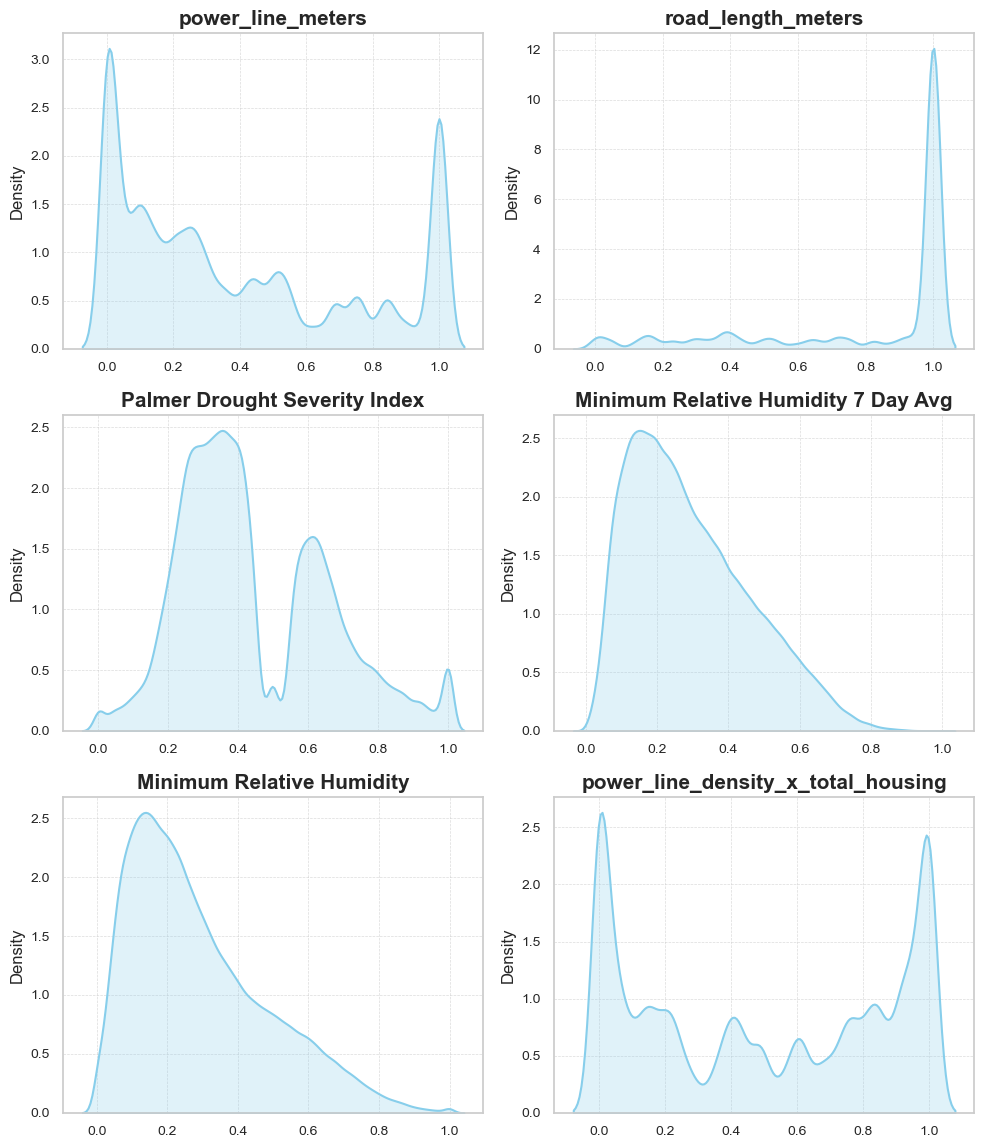

'../plots/features/KDE_{df.columns[0]}.png'

In [41]:
grid_kde(X[ignition_xgb_top5])

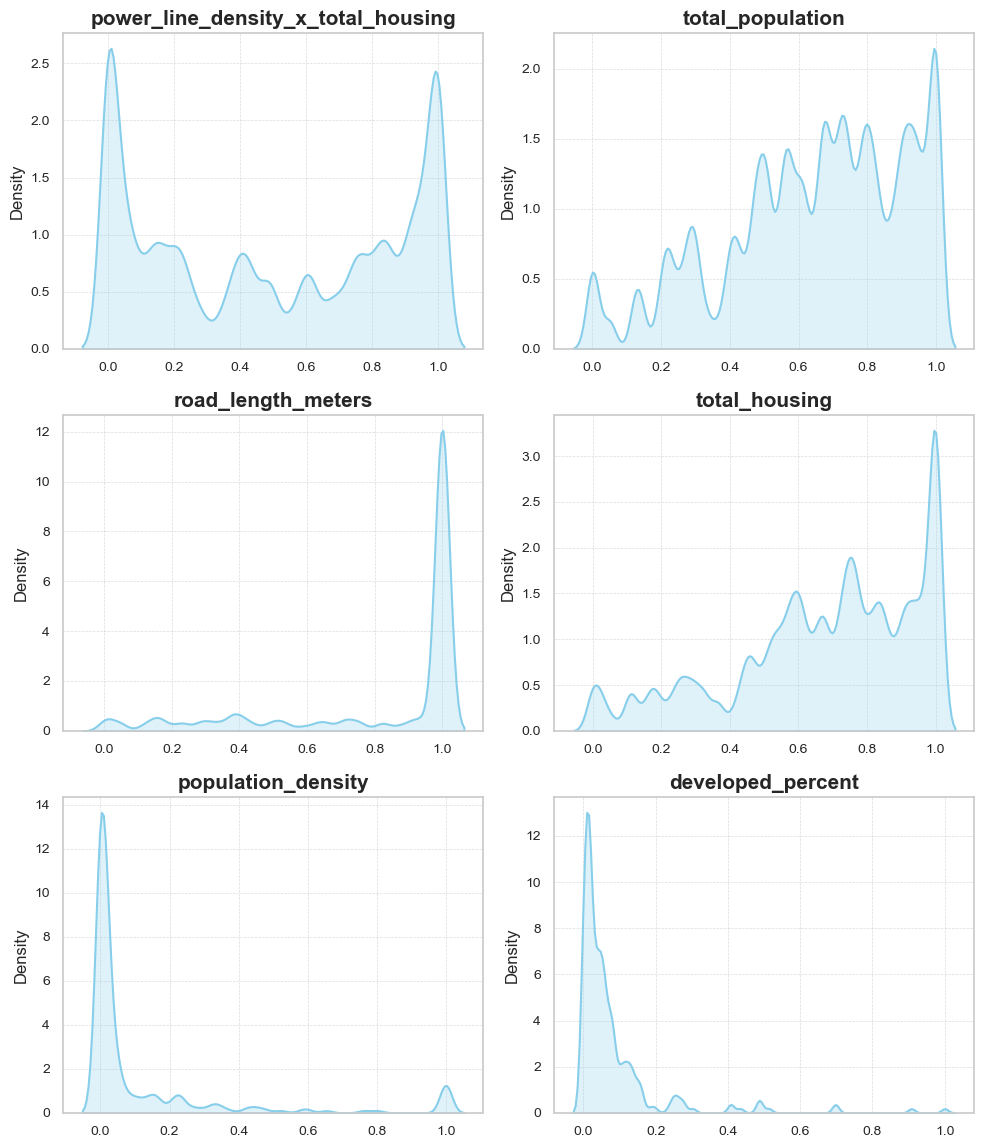

'../plots/features/KDE_{df.columns[0]}.png'

In [42]:
grid_kde(X[ignition_rf_top5])

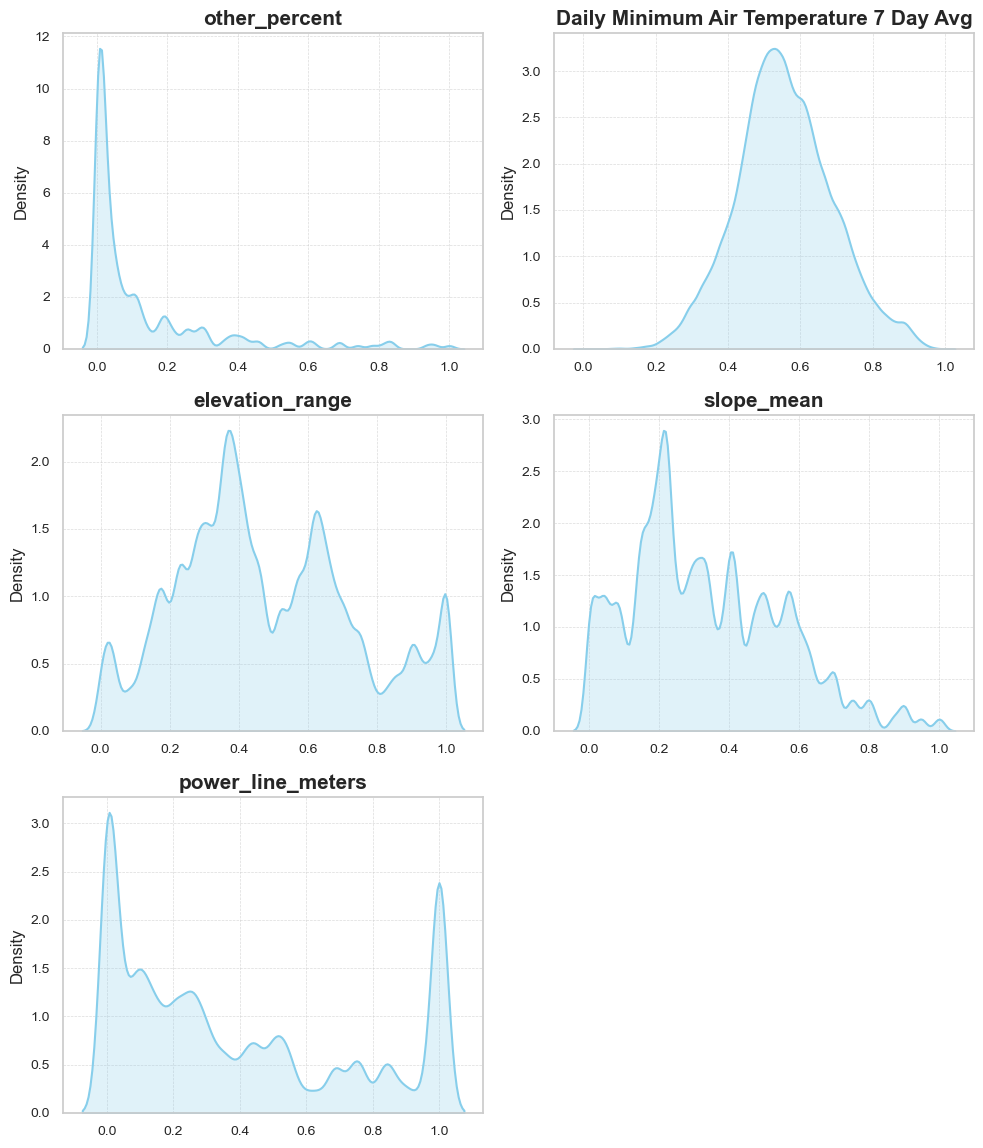

'../plots/features/KDE_{df.columns[0]}.png'

In [43]:
grid_kde(X[spread_xgb_top5])

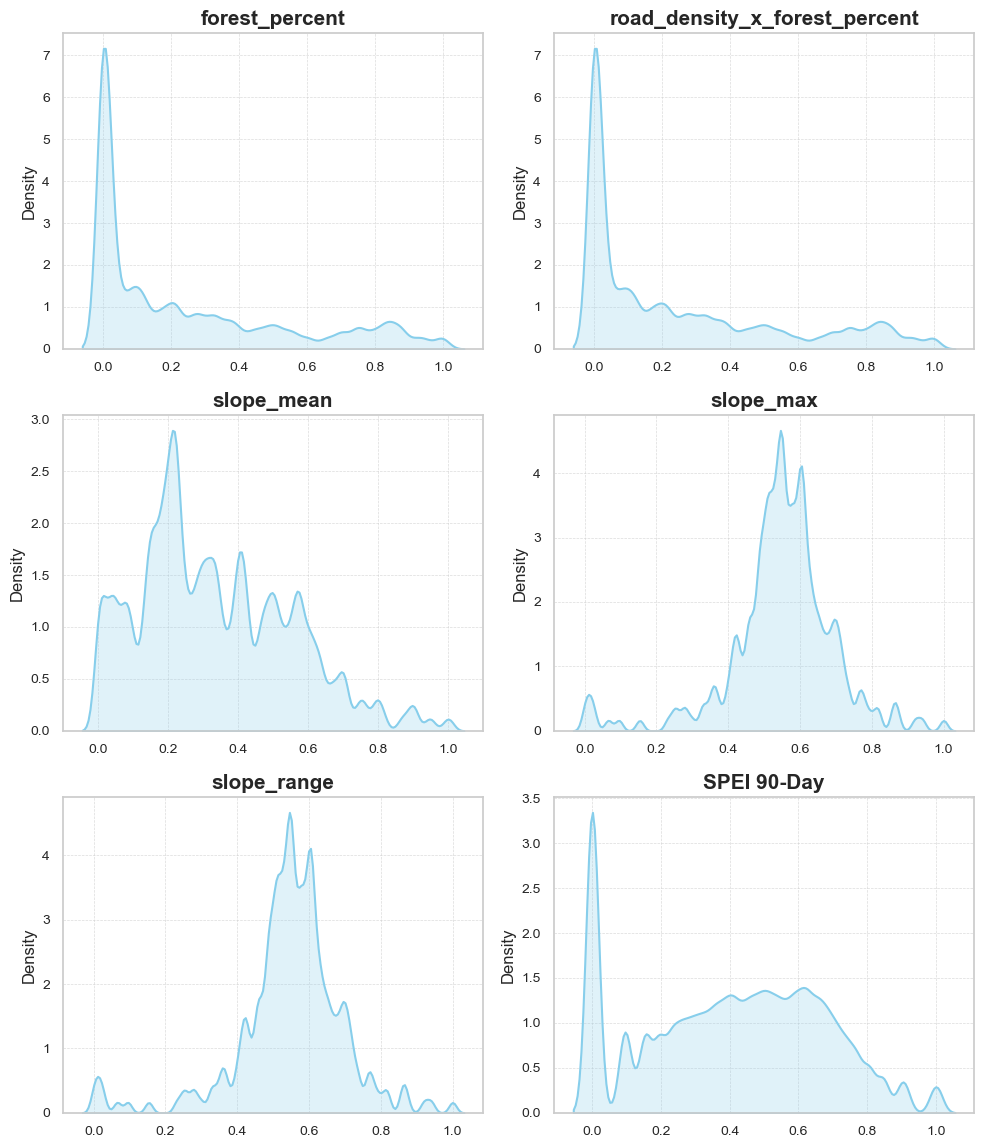

'../plots/features/KDE_{df.columns[0]}.png'

In [44]:
grid_kde(X[spread_rf_top5])

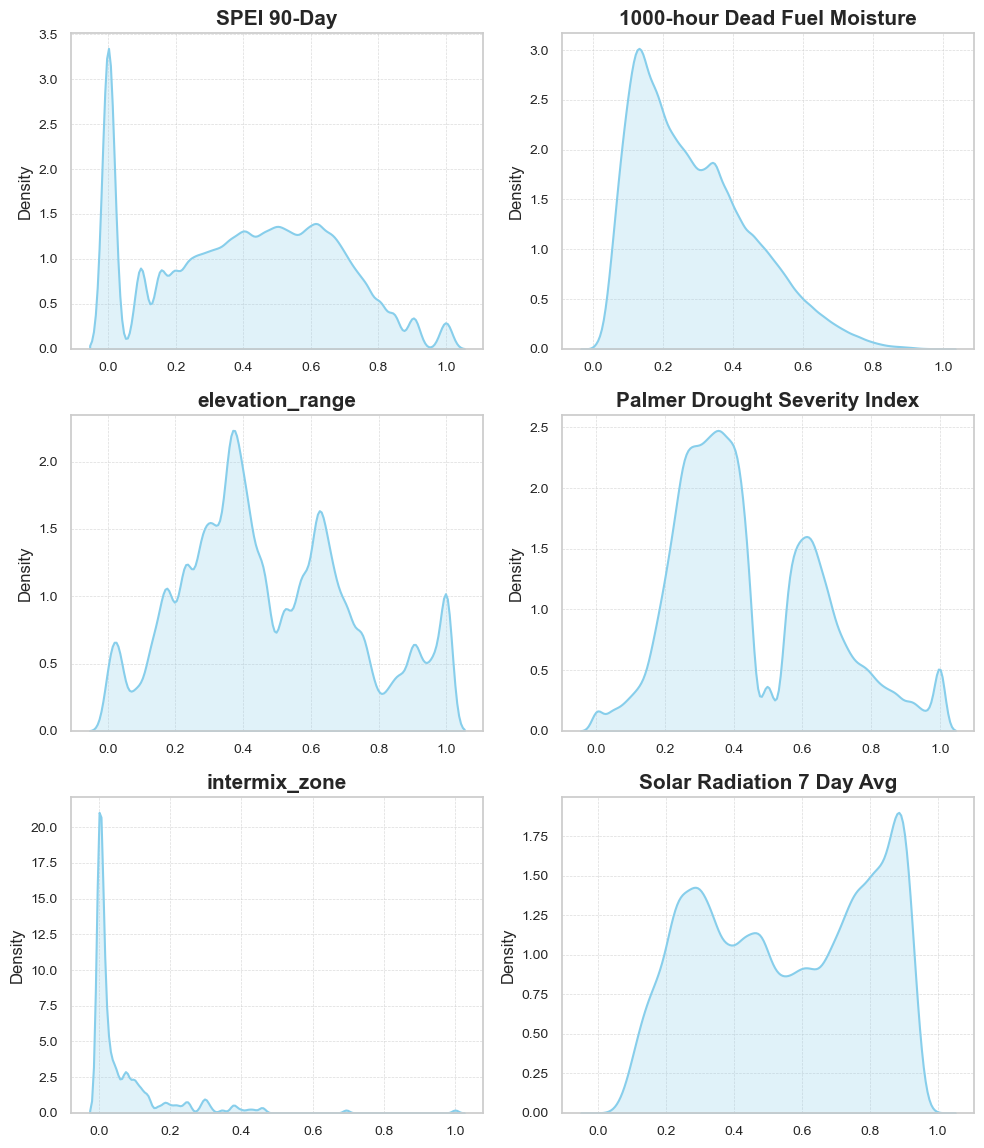

'../plots/features/KDE_{df.columns[0]}.png'

In [45]:
grid_kde(X[damage_xgb_top5])

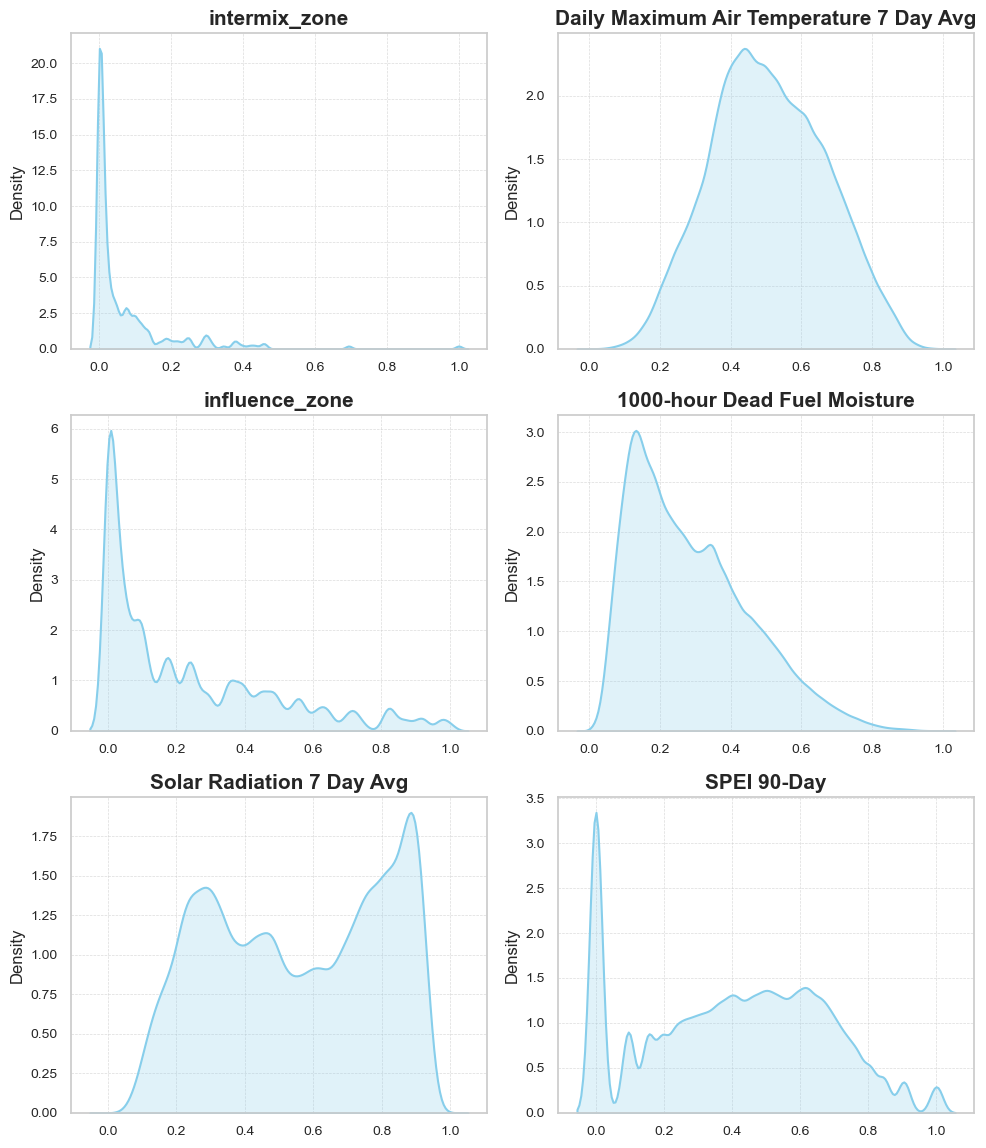

'../plots/features/KDE_{df.columns[0]}.png'

In [46]:
grid_kde(X[damage_rf_top5])